# Model Development - Customer Churn Prediction
This notebook develops and compares different machine learning models for customer churn prediction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Add src to path\n",
sys.path.append('../src')

from data.data_loader import DataLoader
from data.preprocessor import DataPreprocessor
from ml_models.trainer import ModelTrainer

# Set style\n",
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## 1. Data Loading and Preprocessing

In [11]:
# Set up MLflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("customer_churn_model_development")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Current experiment:", mlflow.get_experiment_by_name("customer_churn_model_development"))

MLflow tracking URI: http://127.0.0.1:5000
Current experiment: <Experiment: artifact_location='mlflow-artifacts:/891223193828270379', creation_time=1754392324288, experiment_id='891223193828270379', last_update_time=1754392324288, lifecycle_stage='active', name='customer_churn_model_development', tags={}>


In [18]:
# Load data
data_loader = DataLoader('../data/raw')
df = data_loader.load_training_data()

In [19]:
# NOTE: Run this cell ONLY if you are working with the original dataset.
# If you are using synthetic data or other sources, do NOT run this cell
# as these transformations rely on specific columns and values from the dataset.

# Drop columns that are either identifiers or categorical with many unique values,
# which might not be useful or require special processing.
df = df.drop(columns=['customerID', 'MultipleLines', 'InternetService', 'PaymentMethod'])

# Convert 'gender' column from categorical text ('Female', 'Male') to numeric binary values.
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# Map 'Contract' categorical column to ordinal integers.
contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_mapping)

# Loop over all columns to convert 'Yes'/'No' string columns to 1/0 numeric format.
for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].dropna().unique()
        if set(unique_vals) == {'Yes', 'No'}:
            df[col] = df[col].map({'Yes': 1, 'No': 0})

# Additional handling for columns containing 'Yes', 'No', and 'No internet service'.
# Map 'Yes' to 1, 'No' to 0, and 'No internet service' to -1 to differentiate this special case.
for col in df.select_dtypes(include='object'):
    unique_vals = set(df[col].dropna().unique())
    if unique_vals.issubset({'Yes', 'No', 'No internet service'}):
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': -1})

# Convert to float (with errors='coerce' to safely handle any bad entries)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [20]:
print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean():.2%}")
df.head()

Dataset shape: (7043, 17)
Churn rate: 26.54%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,1,0,0,0,0,0,1,29.85,29.85,0
1,0,0,0,0,34,1,1,0,1,0,0,0,1,0,56.95,1889.50,0
2,0,0,0,0,2,1,1,1,0,0,0,0,0,1,53.85,108.15,1
3,0,0,0,0,45,0,1,0,1,1,0,0,1,0,42.30,1840.75,0
4,1,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1


In [21]:
# Preprocess data
preprocessor = DataPreprocessor()
df_processed = preprocessor.fit_transform(df)

print(f"Processed dataset shape: {df_processed.shape}")
print(f"New features created: {set(df_processed.columns) - set(df.columns)}")

# Save preprocessor for later use
preprocessor.save('../models/artifacts/preprocessor.pkl')
print("Preprocessor saved!")

Processed dataset shape: (7043, 18)
New features created: {'is_new_customer'}
Preprocessor saved!


In [24]:
# Prepare features and target
feature_columns = df_processed.columns

X = df_processed.drop(columns=['Churn'])
y = df_processed['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {list(X.columns)}")

Features shape: (7043, 17)
Target shape: (7043,)
Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'is_new_customer']


In [26]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nChurn rates:")
print(f"Train: {y_train.mean():.2%}")
print(f"Validation: {y_val.mean():.2%}")
print(f"Test: {y_test.mean():.2%}")

Training set: (4507, 17)
Validation set: (1127, 17)
Test set: (1409, 17)

Churn rates:
Train: 26.54%
Validation: 26.53%
Test: 26.54%


## 2. Baseline Models

In [41]:
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42, probability=True)
    }

# Store results
model_results = {}

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    with mlflow.start_run(run_name=f"baseline_{name.lower().replace(' ', '_')}"):
        # Log model parameters
        mlflow.log_params(model.get_params())

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        y_pred_test = model.predict(X_test)

        # Probabilities
        y_proba_train = model.predict_proba(X_train)[:, 1]
        y_proba_val = model.predict_proba(X_val)[:, 1]
        y_proba_test = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        metrics = {
            'train_accuracy': accuracy_score(y_train, y_pred_train),
            'val_accuracy': accuracy_score(y_val, y_pred_val),
            'test_accuracy': accuracy_score(y_test, y_pred_test),
            'train_precision': precision_score(y_train, y_pred_train),
            'val_precision': precision_score(y_val, y_pred_val),
            'test_precision': precision_score(y_test, y_pred_test),
            'train_recall': recall_score(y_train, y_pred_train),
            'val_recall': recall_score(y_val, y_pred_val),
            'test_recall': recall_score(y_test, y_pred_test),
            'train_f1': f1_score(y_train, y_pred_train),
            'val_f1': f1_score(y_val, y_pred_val),
            'test_f1': f1_score(y_test, y_pred_test),
            'train_auc': roc_auc_score(y_train, y_proba_train),
            'val_auc': roc_auc_score(y_val, y_proba_val),
            'test_auc': roc_auc_score(y_test, y_proba_test)
        }

        # Log metrics
        mlflow.log_metrics(metrics)

        # Log model
        mlflow.sklearn.log_model(model, "model")

        # Store results
        model_results[name] = {
            'model': model,
            'metrics': metrics,
            'predictions': {
                'val_pred': y_pred_val,
                'val_proba': y_proba_val,
               'test_pred': y_pred_test,
               'test_proba': y_proba_test
           }
       }
    
        print(f"Validation Accuracy: {metrics['val_accuracy']:.4f}")
        print(f"Validation AUC: {metrics['val_auc']:.4f}")
        print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
        print(f"Test AUC: {metrics['test_auc']:.4f}")

print("\nBaseline models training completed!")


Training Logistic Regression...
Validation Accuracy: 0.8154
Validation AUC: 0.8405
Test Accuracy: 0.7864
Test AUC: 0.8374

Training Random Forest...
Validation Accuracy: 0.7977
Validation AUC: 0.8196
Test Accuracy: 0.7821
Test AUC: 0.8246

Training Gradient Boosting...
Validation Accuracy: 0.8021
Validation AUC: 0.8463
Test Accuracy: 0.7942
Test AUC: 0.8422

Training SVM...
Validation Accuracy: 0.7347
Validation AUC: 0.7978
Test Accuracy: 0.7346
Test AUC: 0.8008

Baseline models training completed!


## 3. Model Comparison

Model Comparison (Validation Set):
           Logistic Regression  Random Forest  Gradient Boosting     SVM
Accuracy                0.8154         0.7977             0.8021  0.7347
Precision               0.6970         0.6592             0.6827  0.0000
Recall                  0.5385         0.4916             0.4749  0.0000
F1                      0.6075         0.5632             0.5602  0.0000
Auc                     0.8405         0.8196             0.8463  0.7978


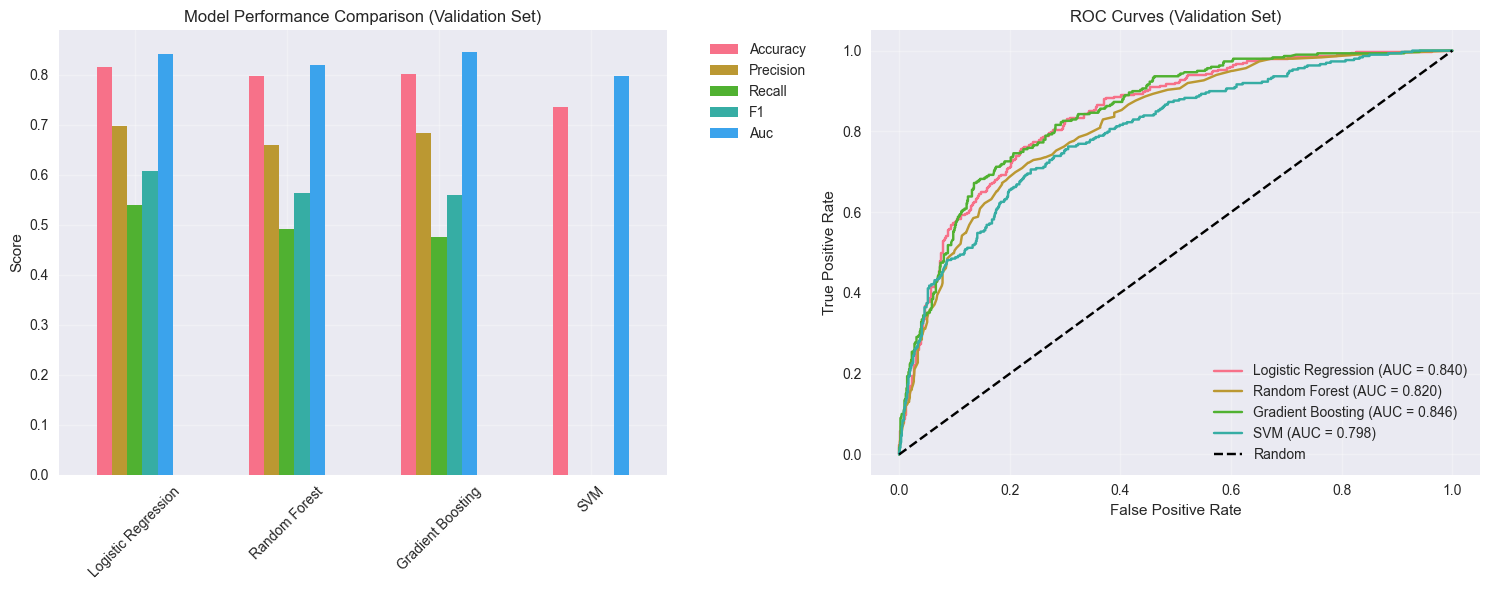


Best model: Gradient Boosting (AUC: 0.8463)


In [43]:
# Create comparison dataframe
comparison_metrics = ['val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_auc']
comparison_df = pd.DataFrame({
    model_name: [model_results[model_name]['metrics'][metric] for metric in comparison_metrics]
    for model_name in model_results.keys()
}, index=[metric.replace('val_', '').title() for metric in comparison_metrics])

print("Model Comparison (Validation Set):")
print(comparison_df.round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot of validation metrics
comparison_df.T.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Model Performance Comparison (Validation Set)')
axes[0].set_ylabel('Score')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# ROC curves
for model_name in model_results.keys():
    y_proba = model_results[model_name]['predictions']['val_proba']
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_score = model_results[model_name]['metrics']['val_auc']
    axes[1].plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (Validation Set)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best model
best_model_name = comparison_df.loc['Auc'].idxmax()
best_auc = comparison_df.loc['Auc'].max()
print(f"\nBest model: {best_model_name} (AUC: {best_auc:.4f})")

## 4. Hyperparameter Tuning

In [46]:
# Hyperparameter tuning for the best model
print(f"Performing hyperparameter tuning for {best_model_name}...")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42)

elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = GradientBoostingClassifier(random_state=42)

elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
    base_model = LogisticRegression(random_state=42, max_iter=1000)

else:  # SVM
    param_grid = {
         'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }
    base_model = SVC(random_state=42, probability=True)

print(f"Parameter grid: {param_grid}")

Performing hyperparameter tuning for Gradient Boosting...
Parameter grid: {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7], 'subsample': [0.8, 0.9, 1.0]}


In [48]:
# Perform grid search
with mlflow.start_run(run_name=f"tuned_{best_model_name.lower().replace(' ', '_')}"):
    grid_search = GridSearchCV(
        base_model, 
        param_grid, 
        cv=5, 
        scoring='accuracy', 
        n_jobs=-1, 
        verbose=1
    )

    print("Starting grid search...")
    grid_search.fit(X_train, y_train)

    # Get best model
    best_tuned_model = grid_search.best_estimator_

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

    # Log best parameters
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("cv_auc_score", grid_search.best_score_)

    # Evaluate tuned model
    y_pred_val_tuned = best_tuned_model.predict(X_val)
    y_proba_val_tuned = best_tuned_model.predict_proba(X_val)[:, 1]
    y_pred_test_tuned = best_tuned_model.predict(X_test)
    y_proba_test_tuned = best_tuned_model.predict_proba(X_test)[:, 1]

    # Calculate metrics for tuned model
    tuned_metrics = {
        'val_accuracy': accuracy_score(y_val, y_pred_val_tuned),
        'val_precision': precision_score(y_val, y_pred_val_tuned),
        'val_recall': recall_score(y_val, y_pred_val_tuned),
        'val_f1': f1_score(y_val, y_pred_val_tuned),
        'val_auc': roc_auc_score(y_val, y_proba_val_tuned),
        'test_accuracy': accuracy_score(y_test, y_pred_test_tuned),
        'test_precision': precision_score(y_test, y_pred_test_tuned),
        'test_recall': recall_score(y_test, y_pred_test_tuned),
        'test_f1': f1_score(y_test, y_pred_test_tuned),
        'test_auc': roc_auc_score(y_test, y_proba_test_tuned)
    }

    # Log metrics
    mlflow.log_metrics(tuned_metrics)

    # Log model
    mlflow.sklearn.log_model(best_tuned_model, "model")

    print(f"\nTuned model performance:")
    print(f"Validation AUC: {tuned_metrics['val_auc']:.4f}")
    print(f"Test AUC: {tuned_metrics['test_auc']:.4f}")

    # Compare with baseline
    baseline_val_auc = model_results[best_model_name]['metrics']['val_auc']
    improvement = tuned_metrics['val_auc'] - baseline_val_auc
    print(f"\nImprovement over baseline: {improvement:+.4f} AUC points")

Starting grid search...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation score: 0.8019

Tuned model performance:
Validation AUC: 0.8472
Test AUC: 0.8439

Improvement over baseline: +0.0008 AUC points


## 5. Feature Importance Analysis

Feature Importance:
             feature  importance
12          Contract    0.441083
4             tenure    0.191716
14    MonthlyCharges    0.179714
15      TotalCharges    0.043759
6     OnlineSecurity    0.029196
9        TechSupport    0.022263
7       OnlineBackup    0.019837
13  PaperlessBilling    0.019277
10       StreamingTV    0.018812
1      SeniorCitizen    0.010899
5       PhoneService    0.009255
8   DeviceProtection    0.006447
11   StreamingMovies    0.003512
3         Dependents    0.003092
0             gender    0.000948
2            Partner    0.000191
16   is_new_customer    0.000000


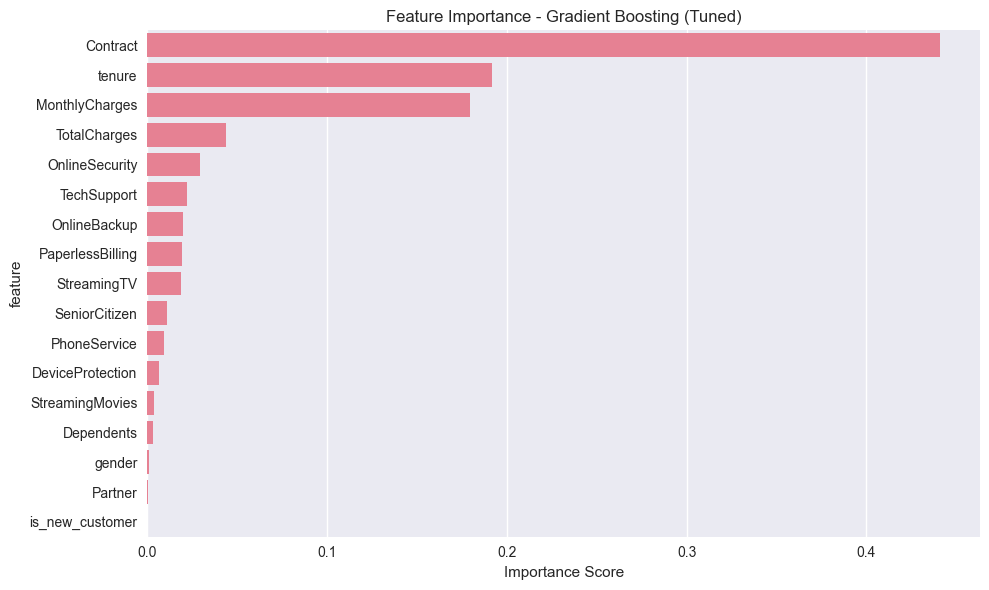

In [60]:
# Feature importance analysis
if hasattr(best_tuned_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_tuned_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("Feature Importance:")
    print(feature_importance)

    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature')
    plt.title(f'Feature Importance - {best_model_name} (Tuned)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    # Log feature importance
    feature_importance_dict = dict(zip(feature_importance['feature'], feature_importance['importance']))
    with mlflow.start_run(run_name="feature_importance_analysis"):
        for feature, importance in feature_importance_dict.items():
            mlflow.log_metric(f"importance_{feature}", importance)

else:
    print(f"Feature importance not available for {best_model_name}")

## 6. Model Interpretation

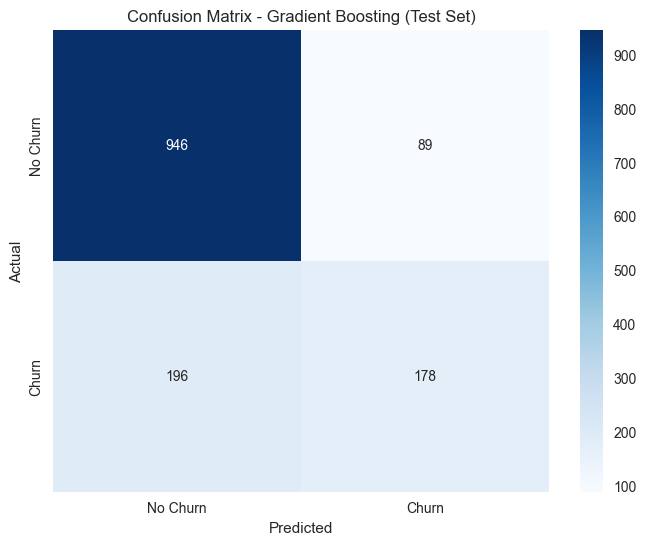


Classification Report - Gradient Boosting (Test Set):
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [61]:
# Confusion matrix for best model
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name} (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print(f"\nClassification Report - {best_model_name} (Test Set):")
print(classification_report(y_test, y_pred_test_tuned, target_names=['No Churn', 'Churn']))

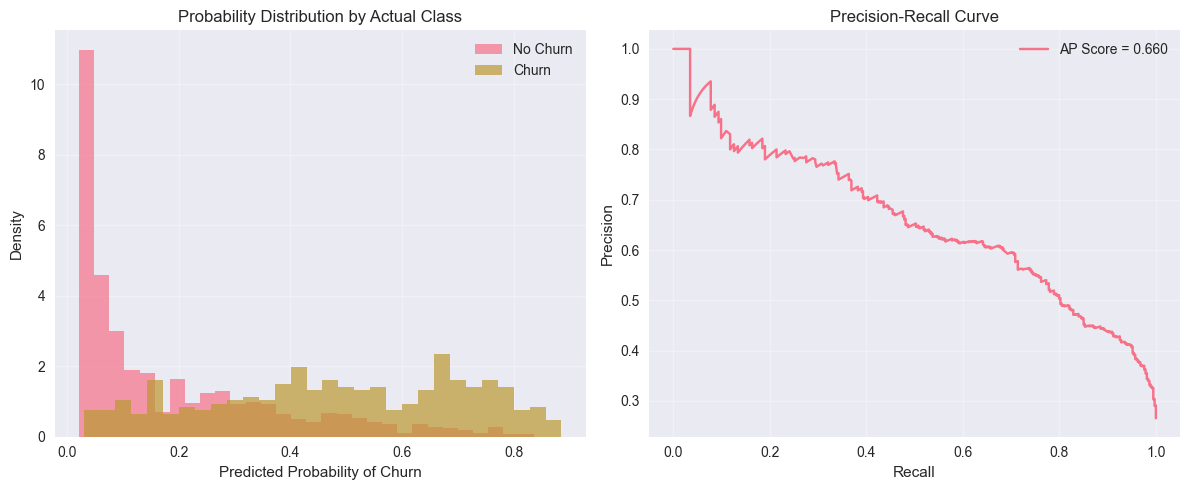

In [62]:
# Probability distribution analysis
plt.figure(figsize=(12, 5))

# Subplot 1: Probability distributions
plt.subplot(1, 2, 1)
plt.hist(y_proba_test_tuned[y_test == 0], bins=30, alpha=0.7, label='No Churn', density=True)
plt.hist(y_proba_test_tuned[y_test == 1], bins=30, alpha=0.7, label='Churn', density=True)
plt.xlabel('Predicted Probability of Churn')
plt.ylabel('Density')
plt.title('Probability Distribution by Actual Class')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_test_tuned)
avg_precision = average_precision_score(y_test, y_proba_test_tuned)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'AP Score = {avg_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Validation and Cross-Validation

In [64]:
# Cross-validation analysis
from sklearn.model_selection import cross_validate

print("Performing cross-validation analysis...")

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(best_tuned_model, X_train, y_train, 
                           cv=5, scoring=scoring, return_train_score=True)

# Create results dataframe
cv_summary = pd.DataFrame({
    'Metric': [metric.replace('test_', '').title() for metric in scoring],
    'Mean CV Score': [cv_results[f'test_{metric}'].mean() for metric in scoring],
    'Std CV Score': [cv_results[f'test_{metric}'].std() for metric in scoring],
    'Mean Train Score': [cv_results[f'train_{metric}'].mean() for metric in scoring],
    'Std Train Score': [cv_results[f'train_{metric}'].std() for metric in scoring]
    })

print("\nCross-Validation Results:")
print(cv_summary.round(4))

# Check for overfitting
cv_summary['Overfitting'] = cv_summary['Mean Train Score'] - cv_summary['Mean CV Score']
print("\nOverfitting Analysis (Train - CV):")
print(cv_summary[['Metric', 'Overfitting']].round(4))

Performing cross-validation analysis...

Cross-Validation Results:
      Metric  Mean CV Score  Std CV Score  Mean Train Score  Std Train Score
0   Accuracy         0.8019        0.0112            0.8205           0.0024
1  Precision         0.6685        0.0392            0.7145           0.0080
2     Recall         0.5084        0.0046            0.5391           0.0103
3         F1         0.5769        0.0124            0.6144           0.0066
4    Roc_Auc         0.8430        0.0098            0.8710           0.0016

Overfitting Analysis (Train - CV):
      Metric  Overfitting
0   Accuracy       0.0186
1  Precision       0.0460
2     Recall       0.0307
3         F1       0.0375
4    Roc_Auc       0.0280


## 8. Model Saving and Registration

In [65]:
# Register the best model
with mlflow.start_run(run_name="final_model_registration"):
    # Log final model with all metadata
    mlflow.log_params({
        'model_type': best_model_name,
        'features_used': feature_columns,
        'preprocessing': 'StandardScaler + Feature Engineering',
        'validation_strategy': '5-fold CV'
    })
    
    # Log final metrics
    mlflow.log_metrics({
        'final_test_accuracy': tuned_metrics['test_accuracy'],
        'final_test_auc': tuned_metrics['test_auc'],
        'final_test_f1': tuned_metrics['test_f1'],
        'cv_auc_mean': cv_results['test_roc_auc'].mean(),
        'cv_auc_std': cv_results['test_roc_auc'].std()
    })

    # Log model
    mlflow.sklearn.log_model(
        best_tuned_model, 
        "model",
        registered_model_name="customer_churn_predictor"
    )
   
    # Log feature importance if available
    if hasattr(best_tuned_model, 'feature_importances_'):
        importance_dict = dict(zip(feature_columns, best_tuned_model.feature_importances_))
        mlflow.log_dict(importance_dict, "feature_importance.json")
    
    print(f"Model registered successfully!")
    print(f"Model name: customer_churn_predictor")
    print(f"Test AUC: {tuned_metrics['test_auc']:.4f}")
    print(f"Test Accuracy: {tuned_metrics['test_accuracy']:.4f}")

Successfully registered model 'customer_churn_predictor'.
2025/08/05 15:40:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: customer_churn_predictor, version 1


Model registered successfully!
Model name: customer_churn_predictor
Test AUC: 0.8439
Test Accuracy: 0.7977


Created version '1' of model 'customer_churn_predictor'.


## 9. Model Summary and Next Steps

In [69]:
# Final model summary
print("Model Development Summary")
print("=" * 50)
print(f"Best Model: {best_model_name}")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"")
print(f"Performance Metrics (Test Set):")
print(f"Accuracy: {tuned_metrics['test_accuracy']:.4f}")
print(f"Precision: {tuned_metrics['test_precision']:.4f}")
print(f"Recall: {tuned_metrics['test_recall']:.4f}")
print(f"F1-Score: {tuned_metrics['test_f1']:.4f}")
print(f"AUC-ROC: {tuned_metrics['test_auc']:.4f}")
print(f"")
print(f"Cross-Validation AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std()*2:.4f})")

if hasattr(best_tuned_model, 'feature_importances_'):
    top_features = feature_importance.head(3)
    print(f"\nTop 3 Important Features:")
    for _, row in top_features.iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")

Model Development Summary
Best Model: Gradient Boosting
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

Performance Metrics (Test Set):
Accuracy: 0.7977
Precision: 0.6667
Recall: 0.4759
F1-Score: 0.5554
AUC-ROC: 0.8439

Cross-Validation AUC: 0.8430 (+/- 0.0197)

Top 3 Important Features:
  Contract: 0.4411
  tenure: 0.1917
  MonthlyCharges: 0.1797


In [72]:
# Save model artifacts locally for deployment
import joblib

# Save final model
joblib.dump(best_tuned_model, '../models/production/final_model.pkl')

# Save model metadata
model_metadata = {
    'model_type': best_model_name,
    'parameters': grid_search.best_params_,
    'features': feature_columns,
    'performance': tuned_metrics,
    'cv_results': {
        'mean_auc': cv_results['test_roc_auc'].mean(),
        'std_auc': cv_results['test_roc_auc'].std()
    },
    'training_date': pd.Timestamp.now().isoformat()
    }

import json
with open('../models/production/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2, default=str)

print("Model artifacts saved locally for deployment")
print("Model development completed successfully!")

Model artifacts saved locally for deployment
Model development completed successfully!
